# Notebook 03: Preprocessing — Label Gabungan (18 Kelas)

In [1]:
# Cell 1 - Import libraries
import os, json, random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import mediapipe as mp
import warnings
warnings.filterwarnings('ignore')

print(f"OpenCV   : {cv2.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"MediaPipe: {mp.__version__}")

OpenCV   : 4.13.0
NumPy    : 2.4.3
MediaPipe: 0.10.33


In [2]:
# Cell 2 - Load config dari notebook 01
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
DATA_ROOT    = BASE_DIR / 'Dependent'
OUTPUT_ROOT  = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'dependent'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES          = cfg['data']['classes']
CLASSES_ANGKA    = cfg['data']['classes_angka']
CLASSES_ALPHABET = cfg['data']['classes_alphabet']
CLASSES_KATA     = cfg['data']['classes_kata']
SPLITS           = cfg['data']['splits']

TARGET_FRAMES = 30
LIP_SIZE      = (96, 96)
LIP_MARGIN    = 0.30
RESIZE_TO     = (224, 224)

print(f"DATA_ROOT : {DATA_ROOT}")
print(f"OUTPUT    : {OUTPUT_ROOT}")
print(f"Classes   : {len(CLASSES)} label — {CLASSES}")
print(f"Splits    : {SPLITS}")

DATA_ROOT : /home/wipra-ranum/Documents/Skripsi/LipReading/Dependent
OUTPUT    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Classes   : 18 label — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Splits    : ['train', 'val', 'test']


In [3]:
# Cell 3 - Landmark bibir dari MediaPipe FACEMESH_LIPS
# ref: https://github.com/google/mediapipe/blob/master/mediapipe/python/solutions/face_mesh_connections.py

OUTER_LIP = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375,
             291, 409, 270, 269, 267,  0, 37,  39,  40, 185]
INNER_LIP = [78,  95, 88, 178, 87, 14, 317, 402, 318, 324,
             308, 415, 310, 311, 312, 13,  82,  81,  80, 191]

LIP_LANDMARKS = list(set(OUTER_LIP + INNER_LIP))

print(f"Total landmark bibir: {len(LIP_LANDMARKS)} titik")

Total landmark bibir: 40 titik


In [4]:
# Cell 4 - Init MediaPipe (API baru untuk versi 0.10+)
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# download model dulu kalau belum ada
import urllib.request
model_path = Path('/home/wipra-ranum/Documents/Skripsi/LipReading/face_landmarker.task')

if not model_path.exists():
    print("Downloading face landmarker model...")
    url = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
    urllib.request.urlretrieve(url, model_path)
    print("Download selesai ✓")

base_options  = python.BaseOptions(model_asset_path=str(model_path))
face_options  = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)
face_landmarker = vision.FaceLandmarker.create_from_options(face_options)

print(f"MediaPipe {mp.__version__} siap ✓ (Tasks API)")

MediaPipe 0.10.33 siap ✓ (Tasks API)


W0000 00:00:1775103051.874045   25215 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775103051.914390   25215 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775103051.917227   25232 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Graphics (RPL-P)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775103051.919817   25221 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775103051.934184   25223 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


---
## Fungsi Preprocessing

In [5]:
# Cell 5 - Extract semua frame
def extract_all_frames(video_path, resize_to=(224, 224)):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.resize(frame, resize_to))
    cap.release()
    return frames

In [6]:
# Cell 6 - Deteksi bibir di semua frame (Tasks API)
def get_lip_bbox(landmarks, h, w, margin=0.30):
    coords = np.array([[int(landmarks[i].x * w),
                        int(landmarks[i].y * h)] for i in LIP_LANDMARKS])
    x0, y0 = coords.min(axis=0)
    x1, y1 = coords.max(axis=0)
    bw, bh  = x1 - x0, y1 - y0
    x0 = max(0, int(x0 - bw * margin))
    y0 = max(0, int(y0 - bh * margin))
    x1 = min(w, int(x1 + bw * margin))
    y1 = min(h, int(y1 + bh * margin))
    return x0, y0, x1, y1


def detect_lips_all_frames(frames, detector, margin=0.30):
    lip_regions, detect_mask = [], []
    for frame in frames:
        h, w   = frame.shape[:2]
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)

        if result.face_landmarks:
            lm           = result.face_landmarks[0]
            x0,y0,x1,y1 = get_lip_bbox(lm, h, w, margin)
            crop         = frame[y0:y1, x0:x1]
            if crop.size > 0:
                lip_regions.append(crop)
                detect_mask.append(True)
                continue

        lip_regions.append(None)
        detect_mask.append(False)
    return lip_regions, detect_mask

In [7]:
# Cell 7 - Pilih 30 frame berdasarkan perubahan bibir
def select_top30_by_lip_motion(lip_regions, detect_mask, target_n=30):
    valid = [i for i, ok in enumerate(detect_mask) if ok]
    if not valid:
        return None

    thumbs = {i: cv2.cvtColor(cv2.resize(lip_regions[i], (32, 32)),
                              cv2.COLOR_BGR2GRAY).astype(np.float32)
              for i in valid}

    scores = {}
    prev   = None
    for i in valid:
        scores[i] = 0.0 if prev is None else np.abs(thumbs[i] - thumbs[prev]).mean()
        prev = i

    if len(valid) <= target_n:
        sel = valid.copy()
        while len(sel) < target_n:
            sel.append(valid[-1])
        return sel

    top = sorted(scores, key=scores.get, reverse=True)[:target_n]
    return sorted(top)

In [8]:
# Cell 8 - Crop & resize 30 frame terpilih
def crop_selected_frames(lip_regions, selected, lip_size=(96, 96)):
    crops = []
    for i in selected:
        c = lip_regions[i]
        crops.append(cv2.resize(c, lip_size) if c is not None
                     else np.zeros((*lip_size, 3), dtype=np.uint8))
    return np.array(crops, dtype=np.uint8)

In [9]:
# Cell 9 - Pipeline lengkap 1 video
def preprocess_video(video_path, detector):
    frames = extract_all_frames(video_path, RESIZE_TO)
    if not frames:
        return None, 'no frames'

    lip_regions, detect_mask = detect_lips_all_frames(frames, detector, LIP_MARGIN)
    if not any(detect_mask):
        return None, 'no face'

    selected = select_top30_by_lip_motion(lip_regions, detect_mask, TARGET_FRAMES)
    if selected is None:
        return None, 'selection failed'

    return crop_selected_frames(lip_regions, selected, LIP_SIZE), 'ok'

---
## Test Pipeline

In [10]:
# Cell 10 - Test di 1 video dari tiap kategori
test_samples = {
    'Angka'   : CLASSES_ANGKA[0],
    'Alphabet': CLASSES_ALPHABET[0],
    'Kata'    : CLASSES_KATA[0],
}

for kat, cls in test_samples.items():
    vids = sorted((DATA_ROOT / 'train' / cls).glob('*.mp4'))
    if not vids:
        print(f"[SKIP] {kat}/{cls} — tidak ada video")
        continue

    lip_seq, status = preprocess_video(vids[0], face_landmarker)  # ganti ke face_landmarker

    if lip_seq is not None:
        print(f"{kat:8s} | kelas '{cls}' | shape {lip_seq.shape} | {status}")
    else:
        print(f"{kat:8s} | kelas '{cls}' | GAGAL: {status}")

Angka    | kelas '1' | shape (30, 96, 96, 3) | ok
Alphabet | kelas 'a' | shape (30, 96, 96, 3) | ok
Kata     | kelas 'buku' | shape (30, 96, 96, 3) | ok


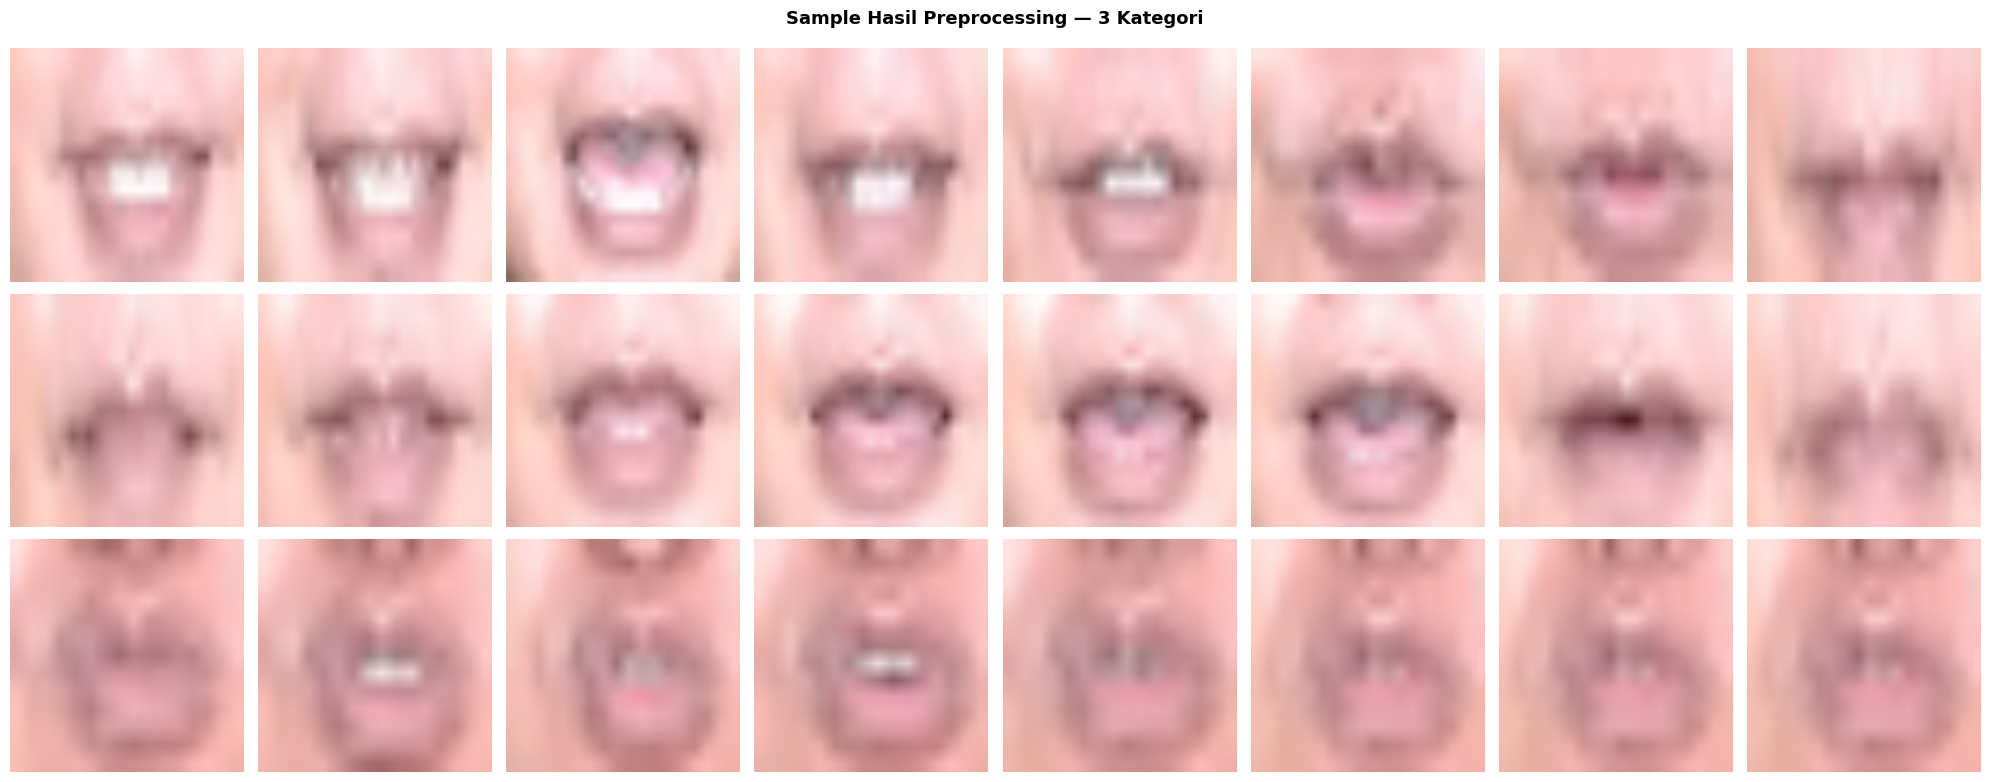

Saved: test_preprocessing.png


In [11]:
# Cell 11 - Visualisasi hasil test (1 video per kategori, 8 frame)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Sample Hasil Preprocessing — 3 Kategori', fontsize=13, fontweight='bold')

for row, (kat, cls) in enumerate(test_samples.items()):
    vids = sorted((DATA_ROOT / 'train' / cls).glob('*.mp4'))
    if not vids:
        continue
    lip_seq, _ = preprocess_video(vids[0], face_landmarker)
    if lip_seq is None:
        continue

    for col, fi in enumerate(np.linspace(0, 29, 8, dtype=int)):
        ax = axes[row][col]
        ax.imshow(cv2.cvtColor(lip_seq[fi], cv2.COLOR_BGR2RGB))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f"{kat}\n'{cls}'", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: test_preprocessing.png")

---
## Batch Processing

In [12]:
# Cell 12 - Hitung video sebelum batch
total = 0
for split in SPLITS:
    sub = 0
    for cls in CLASSES:
        n    = len(list((DATA_ROOT / split / cls).glob('*.mp4')))
        sub  += n
        total += n
    print(f"{split:5s}: {sub} video")

print(f"\nTotal   : {total} video")
print(f"Estimasi: ~{total*0.5/60:.0f}–{total*1.2/60:.0f} menit")

train: 2520 video
val  : 720 video
test : 360 video

Total   : 3600 video
Estimasi: ~30–72 menit


In [13]:
# Cell 13 - Buat folder output
for split in SPLITS:
    for cls in CLASSES:
        (OUTPUT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

print(f"Folder output siap → {OUTPUT_ROOT}")

Folder output siap → /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips


In [14]:
# Cell 14 - Batch preprocessing semua kelas & split
ok = 0
fail = 0
fail_log = []

for split in SPLITS:
    print(f"\n--- {split.upper()} ---")
    for cls in CLASSES:
        videos  = sorted((DATA_ROOT / split / cls).glob('*.mp4'))
        out_dir = OUTPUT_ROOT / split / cls

        for vp in tqdm(videos, desc=f"{split}/{cls}", leave=False):
            out_path = out_dir / f"{vp.stem}.npy"
            if out_path.exists():
                ok += 1
                continue

            lip_seq, status = preprocess_video(vp, face_landmarker)
            if lip_seq is not None:
                np.save(out_path, lip_seq)
                ok += 1
            else:
                fail += 1
                fail_log.append({'split': split, 'class': cls,
                                 'file': vp.name, 'reason': status})

print(f"\nSelesai! Berhasil: {ok} | Gagal: {fail} | Success rate: {ok/(ok+fail)*100:.1f}%")


--- TRAIN ---



--- VAL ---



--- TEST ---



Selesai! Berhasil: 3600 | Gagal: 0 | Success rate: 100.0%


---
## Verifikasi Output

In [15]:
# Cell 15 - Verifikasi jumlah file mp4 vs npy
rows = []
for split in SPLITS:
    for cls in CLASSES:
        n_src = len(list((DATA_ROOT    / split / cls).glob('*.mp4')))
        n_out = len(list((OUTPUT_ROOT  / split / cls).glob('*.npy')))
        rows.append({'split': split, 'class': cls, 'mp4': n_src, 'npy': n_out,
                     'selisih': n_src - n_out})

df_ver = pd.DataFrame(rows)
pivot  = df_ver.pivot_table(index='class', columns='split', values='selisih', aggfunc='sum')

print("Selisih (mp4 - npy), idealnya 0 semua:")
print(pivot.to_string())
print(f"\nTotal kurang: {df_ver['selisih'].sum()} file")

Selisih (mp4 - npy), idealnya 0 semua:
split     test  train  val
class                     
1            0      0    0
10           0      0    0
2            0      0    0
3            0      0    0
8            0      0    0
9            0      0    0
a            0      0    0
b            0      0    0
buku         0      0    0
c            0      0    0
d            0      0    0
dia          0      0    0
e            0      0    0
f            0      0    0
keliling     0      0    0
kelompok     0      0    0
saya         0      0    0
sekarang     0      0    0

Total kurang: 0 file


In [16]:
# Cell 16 - Cek shape output
expected = (TARGET_FRAMES, LIP_SIZE[0], LIP_SIZE[1], 3)
err      = 0

for cls in CLASSES:
    files = list((OUTPUT_ROOT / 'train' / cls).glob('*.npy'))
    if not files:
        continue
    arr    = np.load(random.choice(files))
    status = 'OK' if arr.shape == expected else f'ERR {arr.shape}'
    if 'ERR' in status:
        err += 1
    print(f"  kelas {cls:>3}: {arr.shape}  →  {status}")

print(f"\nExpected: {expected}")
print(f"Error   : {err} kelas")

  kelas   1: (30, 96, 96, 3)  →  OK
  kelas   2: (30, 96, 96, 3)  →  OK
  kelas   3: (30, 96, 96, 3)  →  OK
  kelas   8: (30, 96, 96, 3)  →  OK
  kelas   9: (30, 96, 96, 3)  →  OK
  kelas  10: (30, 96, 96, 3)  →  OK
  kelas   a: (30, 96, 96, 3)  →  OK
  kelas   b: (30, 96, 96, 3)  →  OK
  kelas   c: (30, 96, 96, 3)  →  OK
  kelas   d: (30, 96, 96, 3)  →  OK
  kelas   e: (30, 96, 96, 3)  →  OK
  kelas   f: (30, 96, 96, 3)  →  OK
  kelas buku: (30, 96, 96, 3)  →  OK
  kelas dia: (30, 96, 96, 3)  →  OK
  kelas saya: (30, 96, 96, 3)  →  OK
  kelas keliling: (30, 96, 96, 3)  →  OK
  kelas kelompok: (30, 96, 96, 3)  →  OK
  kelas sekarang: (30, 96, 96, 3)  →  OK

Expected: (30, 96, 96, 3)
Error   : 0 kelas


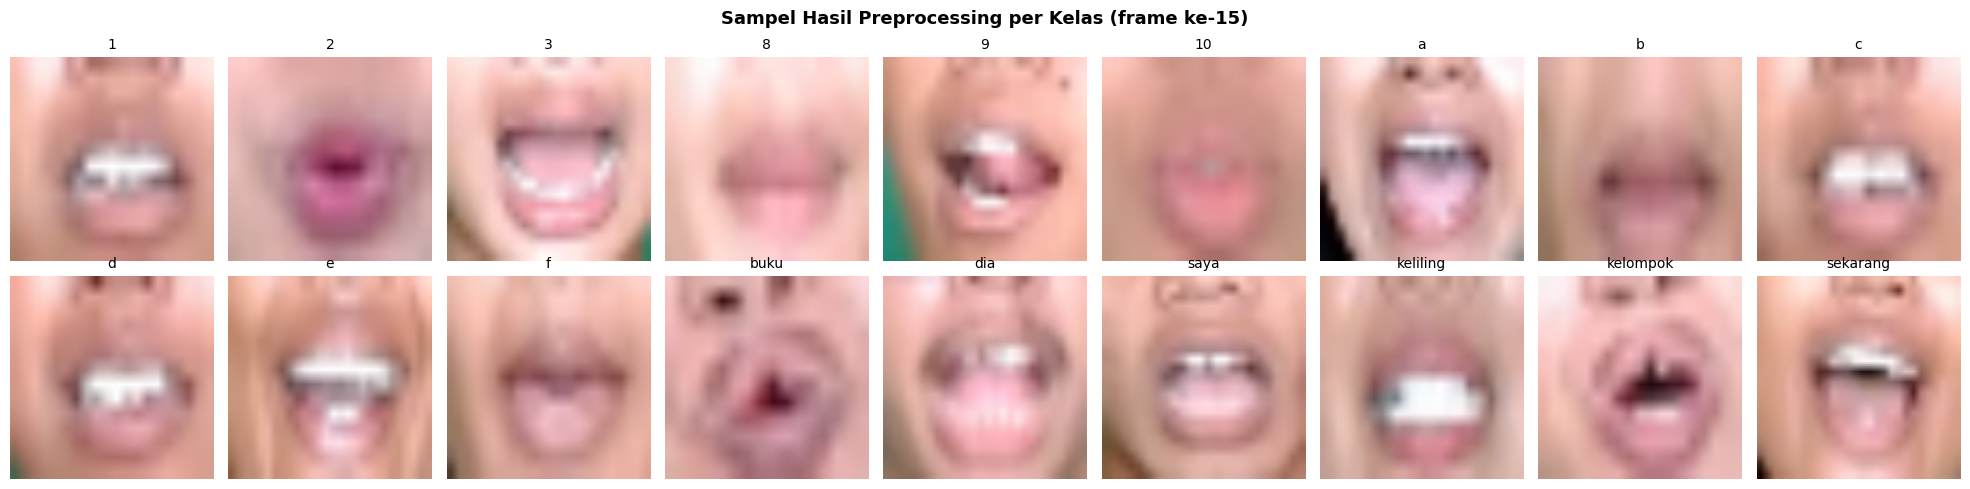

Saved: preprocessed_samples.png


In [17]:
# Cell 17 - Visualisasi sampel hasil per kelas (frame tengah)
n_cls  = len(CLASSES)
n_cols = 9
n_rows = (n_cls + n_cols - 1) // n_cols   # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.2, n_rows*2.5))
fig.suptitle('Sampel Hasil Preprocessing per Kelas (frame ke-15)', fontsize=13, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    ax    = axes.flatten()[idx]
    files = list((OUTPUT_ROOT / 'train' / cls).glob('*.npy'))
    if files:
        seq = np.load(random.choice(files))
        ax.imshow(cv2.cvtColor(seq[15], cv2.COLOR_BGR2RGB))
    ax.set_title(f'{cls}', fontsize=10)
    ax.axis('off')

# sembunyikan subplot kosong
for idx in range(n_cls, n_rows * n_cols):
    axes.flatten()[idx].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preprocessed_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: preprocessed_samples.png")

In [18]:
# Cell 18 - Simpan fail_log kalau ada
if fail_log:
    df_fail = pd.DataFrame(fail_log)
    df_fail.to_csv(RESULTS_DIR / 'fail_log.csv', index=False)
    print(f"Fail log disimpan ({len(fail_log)} video gagal) → fail_log.csv")
    print(df_fail['reason'].value_counts().to_string())
else:
    print("Semua video berhasil diproses ✓")

Semua video berhasil diproses ✓


In [19]:
# Cell 19 - Summary akhir
total_npy = sum(len(list((OUTPUT_ROOT / split / cls).glob('*.npy')))
                for split in SPLITS for cls in CLASSES)

print("=" * 55)
print("  PREPROCESSING SELESAI — Label Gabungan 18 Kelas")
print("=" * 55)
print(f"  Total file .npy : {total_npy}")
print(f"  Output shape    : {(TARGET_FRAMES, *LIP_SIZE, 3)}")
print(f"  Output dir      : {OUTPUT_ROOT}")
print(f"  Gagal           : {fail} video")
print("=" * 55)

for fname in ['test_preprocessing.png', 'preprocessed_samples.png', 'fail_log.csv']:
    exist = (RESULTS_DIR / fname).exists()
    print(f"  {'✓' if exist else '✗'} {fname}")

print("→ Lanjut ke Notebook 04: Optical Flow")

  PREPROCESSING SELESAI — Label Gabungan 18 Kelas
  Total file .npy : 3600
  Output shape    : (30, 96, 96, 3)
  Output dir      : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
  Gagal           : 0 video
  ✓ test_preprocessing.png
  ✓ preprocessed_samples.png
  ✗ fail_log.csv
→ Lanjut ke Notebook 04: Optical Flow
